In [1]:
# =========================================================
# CONNECT GOOGLE DRIVE
# =========================================================

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# =========================================================
# MODULE 1 — CONFIGURATION
# =========================================================

import os
import numpy as np
import tensorflow as tf

# -------------------------------
# General Settings
# -------------------------------
IMAGE_SIZE = 128
CHANNELS = 3
NUM_CLASSES = 7
LATENT_DIM = 100

BATCH_SIZE = 64
EPOCHS = 50

# -------------------------------
# Optimizer Settings
# -------------------------------
LEARNING_RATE = 2e-4
BETA_1 = 0.5
BETA_2 = 0.999

# -------------------------------
# Directories (UPDATED FOR COLAB)
# -------------------------------
BASE_DIR = "/content/drive/MyDrive/CGAN_Project"

DATA_DIR = f"{BASE_DIR}/DAGM_KaggleCombined/Train"
CHECKPOINT_DIR = f"{BASE_DIR}/CheckPoints"
SAMPLE_DIR = f"{BASE_DIR}/Samples"
LOG_DIR = f"{BASE_DIR}/Logs"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(SAMPLE_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

# -------------------------------
# Label Mapping
# -------------------------------
LABEL_MAP = {
    0: "Normal",
    1: "Scratch",
    2: "Crack",
    3: "Dent",
    4: "Pit",
    5: "Rust",
    6: "Stain"
}

print("Configuration Loaded Successfully")

Configuration Loaded Successfully


In [3]:
# =========================================================
# MODULE 2 — DATA LOADING & PREPROCESSING
# =========================================================

from tensorflow.keras.preprocessing.image import ImageDataGenerator

def load_surface_data():

    datagen = ImageDataGenerator(
        rescale=1./127.5,
        preprocessing_function=lambda x: x - 1.0
    )

    generator = datagen.flow_from_directory(
        DATA_DIR,
        target_size=(IMAGE_SIZE, IMAGE_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='sparse',
        shuffle=True
    )

    return generator

train_data = load_surface_data()
print("Data Loader Ready")

Found 150 images belonging to 1 classes.
Data Loader Ready


In [4]:
# =========================================================
# MODULE 3 — GENERATOR
# =========================================================

from tensorflow.keras import layers, Model

def build_generator():

    noise_input = layers.Input(shape=(LATENT_DIM,))
    label_input = layers.Input(shape=(1,), dtype='int32')

    label_embedding = layers.Embedding(NUM_CLASSES, 16)(label_input)
    label_embedding = layers.Flatten()(label_embedding)

    combined = layers.Concatenate()([noise_input, label_embedding])

    x = layers.Dense(8 * 8 * 256)(combined)
    x = layers.Reshape((8, 8, 256))(x)

    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    for filters in [256, 128, 64, 32]:
        x = layers.Conv2DTranspose(filters, 4, strides=2, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)

    output = layers.Conv2D(CHANNELS, 3, padding='same', activation='tanh')(x)

    return Model([noise_input, label_input], output, name="Generator")

generator = build_generator()
generator.summary()

Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 16)     │        112 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer         │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 16)        │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 116)       │          0 │ input_layer[0][0… │
│ (Concatenate)       │                   │            │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16384)     │  1,916,928 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 8, 8, 256) │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 8, 8, 256) │      1,024 │ reshape[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 8, 8, 256) │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 16, 16,    │  1,048,832 │ re_lu[0][0]       │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │      1,024 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 16, 16,    │          0 │ batch_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 32, 32,    │    524,416 │ re_lu_1[0][0]     │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_2  │ (None, 64, 64,    │    131,136 │ re_lu_2[0][0]     │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                 

 Total params: 3,658,035 (13.95 MB)

 Trainable params: 3,656,563 (13.95 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [5]:
# =========================================================
# MODULE 4 — DISCRIMINATOR
# =========================================================

def build_discriminator():

    image_input = layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS))
    x = image_input

    for filters in [64, 128, 256, 512]:
        x = layers.Conv2D(filters, 4, strides=2, padding='same')(x)
        x = layers.LeakyReLU(0.2)(x)
        x = layers.Dropout(0.3)(x)

    x = layers.Flatten()(x)

    validity = layers.Dense(1, activation='sigmoid')(x)
    label = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    return Model(image_input, [validity, label], name="Discriminator")

discriminator = build_discriminator()
discriminator.summary()

Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │      3,136 │ input_layer_2[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64, 64,    │          0 │ leaky_re_lu[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │    131,200 │ dropout[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 32, 32,    │          0 │ conv2d_2[0][0]    │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32, 32,    │          0 │ leaky_re_lu_1[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 16, 16,    │    524,544 │ dropout_1[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 16, 16,    │          0 │ conv2d_3[0][0]    │
│ (LeakyReLU)         │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 16, 16,    │          0 │ leaky_re_lu_2[0]… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 8, 8, 512) │  2,097,664 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_3       │ (None, 8, 8, 512) │          0 │ conv2d_4[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 8, 8, 512) │          0 │ leaky_re_lu_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 32768)     │          0 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │     32,769 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 7)         │    229,383 │ flatten_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,018,696 (11.52 MB)

 Trainable params: 3,018,696 (11.52 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# =========================================================
# MODULE 5 — MONITORING & CONTROL (Keras 3 FIX)
# =========================================================

# -----------------------------------------
# 1️⃣ Separate Optimizers
# -----------------------------------------
optimizer_d = tf.keras.optimizers.Adam(
    learning_rate=LEARNING_RATE,
    beta_1=BETA_1,
    beta_2=BETA_2
)

optimizer_g = tf.keras.optimizers.Adam(
    learning_rate=LEARNING_RATE,
    beta_1=BETA_1,
    beta_2=BETA_2
)

# -----------------------------------------
# 2️⃣ Compile Discriminator
# -----------------------------------------
discriminator.trainable = True

discriminator.compile(
    optimizer=optimizer_d,
    loss=['binary_crossentropy', 'sparse_categorical_crossentropy'],
    metrics=['accuracy', 'accuracy']
)

# -----------------------------------------
# 3️⃣ Build Combined Model
# -----------------------------------------
discriminator.trainable = False

noise_input = layers.Input(shape=(LATENT_DIM,))
label_input = layers.Input(shape=(1,))

generated_image = generator([noise_input, label_input])
validity, target_label = discriminator(generated_image)

combined_model = Model([noise_input, label_input], [validity, target_label])

combined_model.compile(
    optimizer=optimizer_g,
    loss=['binary_crossentropy', 'sparse_categorical_crossentropy']
)

print("Monitoring & Control Ready (Keras 3 Compatible)")


Monitoring & Control Ready (Keras 3 Compatible)


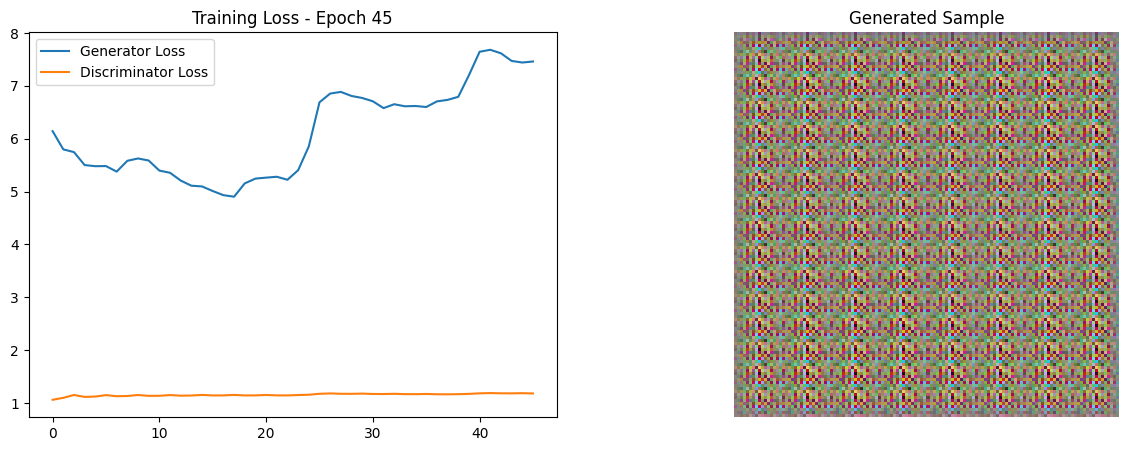

Epoch 45/50 | D: 1.1803 | G: 7.4614
Epoch 46/50 | D: 1.1779 | G: 7.4756
Epoch 47/50 | D: 1.1796 | G: 7.4621
Epoch 48/50 | D: 1.1767 | G: 7.5765
Epoch 49/50 | D: 1.1795 | G: 7.7248


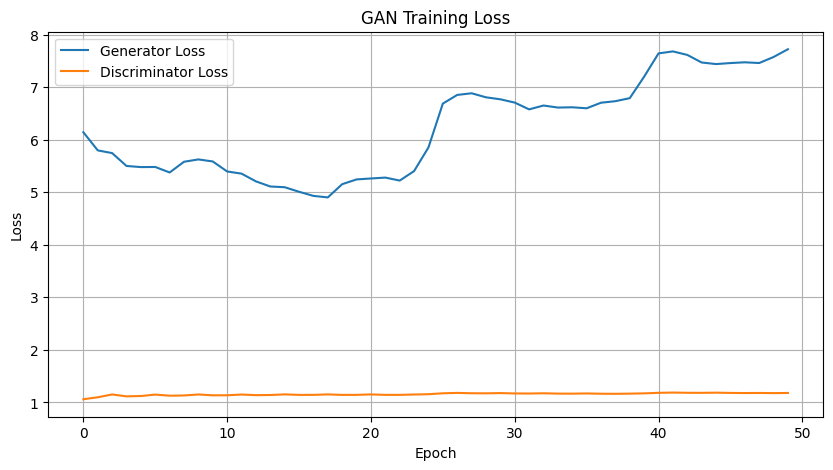

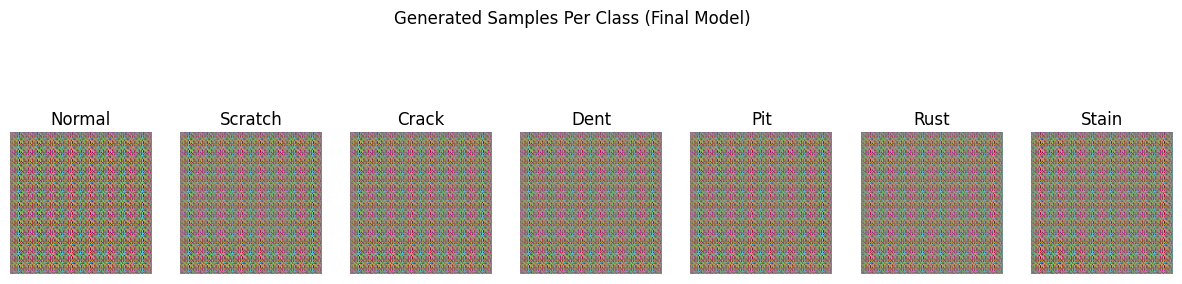

In [20]:
# =========================================================
# MODULE 6 — TRAINING LOOP
# =========================================================

import matplotlib.pyplot as plt

def save_samples(epoch):
    r, c = 2, NUM_CLASSES
    noise = np.random.normal(0, 1, (c, LATENT_DIM))
    labels = np.arange(0, NUM_CLASSES).reshape(-1,1)

    gen_imgs = generator.predict([noise, labels])
    gen_imgs = 0.5 * gen_imgs + 0.5

    fig, axs = plt.subplots(r, c, figsize=(15,6))
    for i in range(c):
        axs[0, i].imshow(gen_imgs[i])
        axs[0, i].set_title(LABEL_MAP[i])
        axs[0, i].axis('off')

    plt.savefig(f"{SAMPLE_DIR}/epoch_{epoch}.png")
    plt.close()

# =========================================================
# LIVE TRAINING VISUALIZATION SETUP
# =========================================================

import matplotlib.pyplot as plt
from IPython.display import clear_output

g_losses = []
d_losses = []

def plot_progress(epoch, gen_imgs):
    clear_output(wait=True)

    plt.figure(figsize=(15,5))

    # -------------------
    # Loss Curve
    # -------------------
    plt.subplot(1,2,1)
    plt.plot(g_losses, label='Generator Loss')
    plt.plot(d_losses, label='Discriminator Loss')
    plt.legend()
    plt.title(f"Training Loss - Epoch {epoch}")

    # -------------------
    # Generated Images
    # -------------------
    plt.subplot(1,2,2)
    gen_imgs = 0.5 * gen_imgs + 0.5
    plt.imshow(gen_imgs[0])
    plt.title("Generated Sample")
    plt.axis('off')

    plt.show()

def train():

    for epoch in range(EPOCHS):

        # ===============================
        # Train Discriminator
        # ===============================
        discriminator.trainable = True

        imgs, labels = next(train_data)
        current_batch_size = imgs.shape[0]

        real_labels = np.ones((current_batch_size, 1)) * 0.9
        fake_labels = np.zeros((current_batch_size, 1))

        labels = labels.reshape(-1, 1)

        noise = np.random.normal(0, 1, (current_batch_size, LATENT_DIM))
        sampled_labels = np.random.randint(0, NUM_CLASSES, current_batch_size).reshape(-1,1)

        gen_imgs = generator.predict([noise, sampled_labels], verbose=0)

        d_loss_real = discriminator.train_on_batch(imgs, [real_labels, labels])
        d_loss_fake = discriminator.train_on_batch(gen_imgs, [fake_labels, sampled_labels])

        d_loss = 0.5 * (d_loss_real[0] + d_loss_fake[0])

        # ===============================
        # Train Generator
        # ===============================
        discriminator.trainable = False

        noise = np.random.normal(0, 1, (current_batch_size, LATENT_DIM))
        sampled_labels = np.random.randint(0, NUM_CLASSES, current_batch_size).reshape(-1,1)

        # Use current_batch_size for generator's 'real' targets as well
        real_gen_labels = np.ones((current_batch_size, 1)) * 0.9

        g_loss = combined_model.train_on_batch(
            [noise, sampled_labels],
            [real_gen_labels, sampled_labels]
        )

        # Store losses
        g_losses.append(g_loss[0])
        d_losses.append(d_loss)


        # ===============================
        # Display Every 5 Epochs
        # ===============================
        if epoch % 5 == 0:
            sample_noise = np.random.normal(0,1,(1,LATENT_DIM))
            sample_label = np.array([[0]])
            sample_img = generator.predict([sample_noise, sample_label], verbose=0)

            plot_progress(epoch, sample_img)

        print(f"Epoch {epoch}/{EPOCHS} | D: {d_loss:.4f} | G: {g_loss[0]:.4f}")

# =========================================================
# FINAL VISUALIZATION AFTER TRAINING
# =========================================================

import matplotlib.pyplot as plt

def final_visualization():

    # ----------------------------
    # Plot Loss Curves
    # ----------------------------
    plt.figure(figsize=(10,5))
    plt.plot(g_losses, label='Generator Loss')
    plt.plot(d_losses, label='Discriminator Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("GAN Training Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ----------------------------
    # Generate One Image Per Class
    # ----------------------------
    noise = np.random.normal(0,1,(NUM_CLASSES, LATENT_DIM))
    labels = np.arange(0, NUM_CLASSES).reshape(-1,1)

    gen_imgs = generator.predict([noise, labels], verbose=0)
    gen_imgs = 0.5 * gen_imgs + 0.5

    plt.figure(figsize=(15,4))
    for i in range(NUM_CLASSES):
        plt.subplot(1, NUM_CLASSES, i+1)
        plt.imshow(gen_imgs[i])
        plt.title(LABEL_MAP[i])
        plt.axis("off")

    plt.suptitle("Generated Samples Per Class (Final Model)")
    plt.show()


train()

final_visualization()

# Save the generator model after training
generator.save(os.path.join(CHECKPOINT_DIR, "G_epoch_50.keras"))


In [22]:
# =========================================================
# MODULE 7 — STREAMLIT APP
# =========================================================

import streamlit as st
from tensorflow.keras.models import load_model
import os # Import os module to use os.path.join

st.title("Surface Defect Synthetic Generator")

# Correct the model loading path to use CHECKPOINT_DIR
model_path = os.path.join(CHECKPOINT_DIR, "G_epoch_50.keras")
model = load_model(model_path)


def generate_images(defect_class, count):
    noise = np.random.normal(0,1,(count, LATENT_DIM))
    labels = np.full((count,1), defect_class)
    imgs = model.predict([noise, labels])
    imgs = 0.5 * imgs + 0.5
    return imgs

selected_defect = st.selectbox("Select Defect Type", list(LABEL_MAP.values()))
count = st.slider("Number of Images", 1, 20, 5)

if st.button("Generate"):
    class_id = list(LABEL_MAP.keys())[list(LABEL_MAP.values()).index(selected_defect)]
    images = generate_images(class_id, count)

    for img in images:
        st.image(img, use_column_width=True)


2026-03-02 09:01:33.758 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-02 09:01:33.759 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-02 09:01:33.761 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-02 09:01:33.939 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-02 09:01:33.940 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-02 09:01:33.941 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-02 09:01:33.943 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-02 09:01:33.944 Session state does not function when running a script without `streamlit run`
2026-03-02 09:01

Found 150 images belonging to 1 classes.
Found 150 images belonging to 1 classes.


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_6 (ReLU)                  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_7 (ReLU)                  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289,479 (16.36 MB)

 Trainable params: 4,289,031 (16.36 MB)

 Non-trainable params: 448 (1.75 KB)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 73s 16s/step - accuracy: 0.5717 - loss: 1.4144 - val_accuracy: 1.0000 - val_loss: 0.0242
Epoch 2/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 313ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 6.9965e-05
Epoch 3/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 292ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 1.8358e-07
Epoch 4/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 287ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 389ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 684ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 370ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 313ms/step - accuracy: 1.0000 - 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


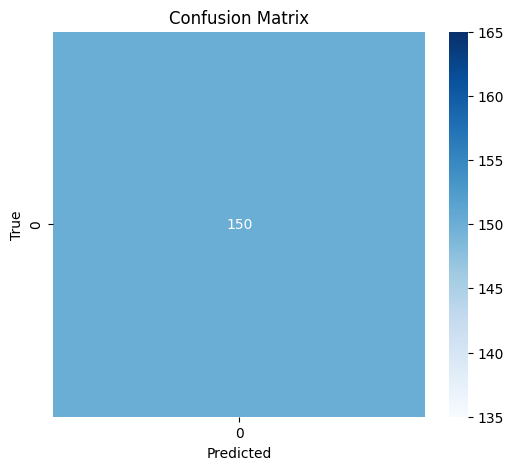

In [24]:
# =========================================================
# MODULE 8 — DEFECT CLASSIFIER (FULL TRAIN + EVALUATE)
# =========================================================

from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# -----------------------------
# 1❣️ Data Loaders
# -----------------------------
train_datagen = ImageDataGenerator(
    rescale=1./127.5,
    preprocessing_function=lambda x: x - 1.0
)

test_datagen = ImageDataGenerator(
    rescale=1./127.5,
    preprocessing_function=lambda x: x - 1.0
)

# Corrected paths for Colab environment
Train_Data_Directory = f"{BASE_DIR}/DAGM_KaggleCombined/Train"

train_loader = train_datagen.flow_from_directory(
    Train_Data_Directory,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=32,
    class_mode='sparse',
    shuffle=True
)

Test_Data_Directory = f"{BASE_DIR}/DAGM_KaggleCombined/Test" # Assuming a 'Test' folder exists alongside 'Train'

test_loader = test_datagen.flow_from_directory(
    Test_Data_Directory,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=32,
    class_mode='sparse',
    shuffle=False
)

# -----------------------------
# 2❣️ Build Classifier
# -----------------------------
def build_classifier():

    inputs = layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS))
    x = inputs

    for filters in [32, 64, 128]:
        x = layers.Conv2D(filters, 3, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        x = layers.MaxPooling2D()(x)

    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    output = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    return Model(inputs, output)

classifier = build_classifier()

classifier.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

classifier.summary()

# -----------------------------
# 3❣️ Train Classifier
# -----------------------------
history = classifier.fit(
    train_loader,
    epochs=15,
    validation_data=test_loader
)

# -----------------------------
# 4❣️ Evaluate
# -----------------------------
test_loss, test_acc = classifier.evaluate(test_loader)
print(f"\nFinal Test Accuracy: {test_acc:.4f}")

# -----------------------------
# 5❣️ Classification Report
# -----------------------------
preds = classifier.predict(test_loader)
y_pred = np.argmax(preds, axis=1)
y_true = test_loader.classes

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))

# -----------------------------
# 6❣️ Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()